<a href="https://colab.research.google.com/github/Premanshukusre/Network-Anomaly-Detection-UNSW-NB15/blob/main/models/Naive_Bayes_UNSW_NB15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Prathamesh Deshmukh

Roll No: CS23115

Subject: Machine Learning

Topic: Network Anomaly Detection

Dataset: UNSW-NB15

Model Used: Naive Bayes

**AIM**

To implement the Naive Bayes algorithm on the UNSW-NB15 dataset for fast and efficient classification of network traffic into normal and anomalous categories.

**DATASET DESCRIPTION**

The UNSW-NB15 dataset is a network intrusion dataset containing labeled data for normal and malicious traffic, with multiple features representing network behavior.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv"
df = pd.read_csv(path)

df.head()

Mounted at /content/drive


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [8]:
df.drop(['id'], axis=1, inplace=True, errors='ignore')

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('label', axis=1)   # features
y = df['label']                # output (0 or 1)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = GaussianNB() # Initialize the Gaussian Naive Bayes model
model.fit(X_train, y_train) # Train the model
y_pred = model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7109370255662841
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      7418
           1       0.71      0.81      0.75      9049

    accuracy                           0.71     16467
   macro avg       0.71      0.70      0.70     16467
weighted avg       0.71      0.71      0.71     16467



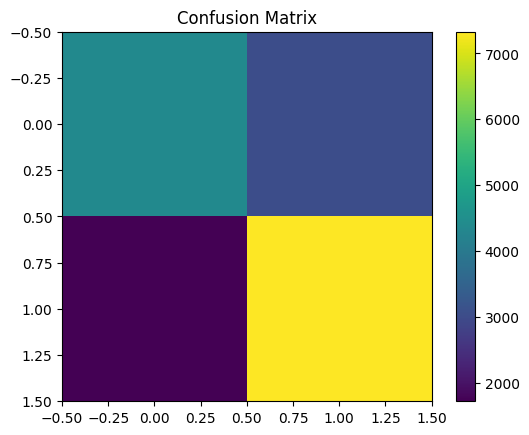

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

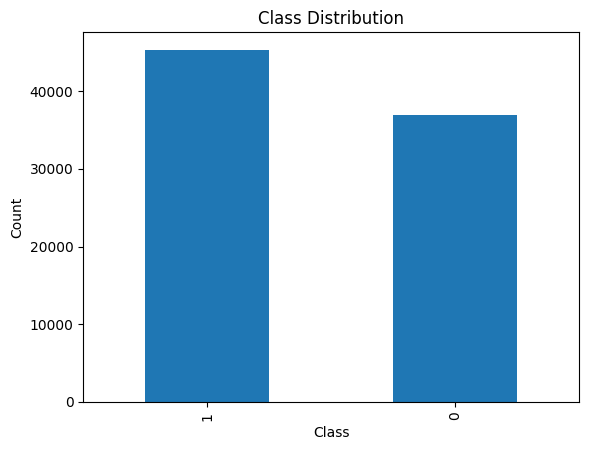

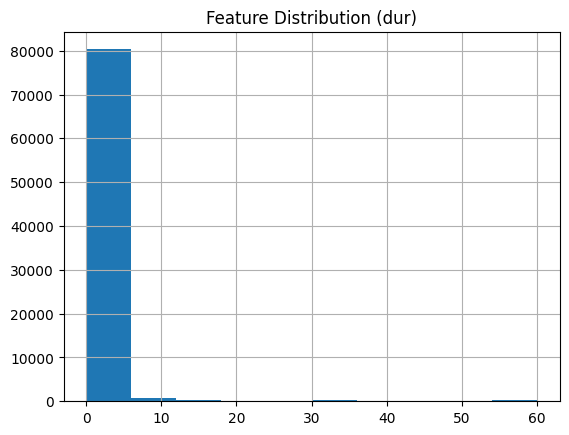

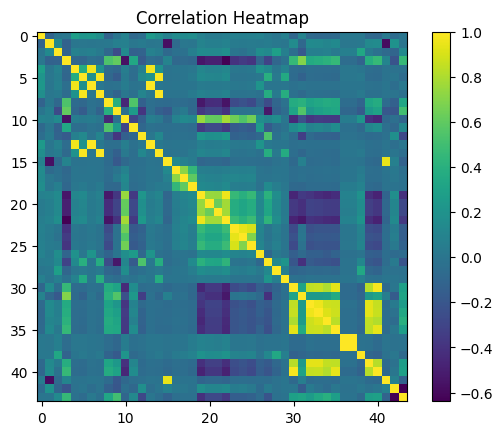

In [15]:
import matplotlib.pyplot as plt

# 1. Class Distribution
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 2. Histogram of any feature
plt.figure()
df['dur'].hist()   # you can change 'dur' to any feature
plt.title("Feature Distribution (dur)")
plt.show()

# 3. Correlation Heatmap
corr = df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()